<a href="https://colab.research.google.com/github/sergeyarefjev/study/blob/main/ml/neural_network_learn_ff/Linear_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 3 - Линейный классификатор (Linear classifier)

В этом задании мы реализуем простейшую модель машинного обучения - линейный классификатор. Линейный классификатор подбирает для каждого класса веса, на которые нужно умножить значение каждого признака и потом сложить вместе.
Тот класс, у которого эта сумма больше, и является предсказанием модели.

В этом задании вы:
- потренируетесь считать градиенты различных многомерных функций
- реализуете подсчет градиентов через линейную модель и функцию потерь softmax
- реализуете процесс тренировки линейного классификатора
- подберете параметры тренировки на практике

Туториал по numpy:  
http://cs231n.github.io/python-numpy-tutorial/

**Перед выполнением задания:**

Запустите файл download_data.sh, чтобы скачать данные, которые мы будем использовать для тренировки.
Установите все необходимые библиотеки, запустив pip install -r requirements.txt (если раньше не работали с pip, вам сюда - https://pip.pypa.io/en/stable/quickstart/).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_gradient
from metrics import multiclass_accuracy
import linear_classifer

In [ ]:
!mkdir data
!cd data
!wget -c http://ufldl.stanford.edu/housenumbers/train_32x32.mat http://ufldl.stanford.edu/housenumbers/test_32x32.mat

--2025-10-01 10:47:01--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  10.9MB/s    in 20s     

2025-10-01 10:47:21 (8.77 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2025-10-01 10:47:21--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Reusing existing connection to ufldl.stanford.edu:80.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  14.6MB/s    in 4.2s    

2025-10-01 10:47:25 (14.6 MB/s) - ‘test_32x32.mat’ saved [64275384/64275384]

FINISHED --2025-10-01 10:47:25--
Total wall clock time: 24s
Downloaded: 2 files, 235M in

# Загружаем данные

Мы будем использовать SVHN - базу данных изображений номеров домов.

In [ ]:
import numpy as np


def check_gradient(f, x, delta=1e-5, tol = 1e-4):
    '''
    Checks the implementation of analytical gradient by comparing
    it to numerical gradient using two-point formula

    Arguments:
      f: function that receives x and computes value and gradient
      x: np array, initial point where gradient is checked
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient

    Return:
      bool indicating whether gradients match or not
    '''

    assert isinstance(x, np.ndarray)
    assert x.dtype == np.float64

    orig_x = x.copy()
    fx, analytic_grad = f(x)
    assert np.all(np.isclose(orig_x, x, tol)), "Functions shouldn't modify input variables"

    assert analytic_grad.shape == x.shape
    analytic_grad = analytic_grad.copy()

    # We will go through every dimension of x and compute numeric
    # derivative for it
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        analytic_grad_at_ix = analytic_grad[ix]
        h = delta
        x[ix] += h
        f_1 = f(x)
        x[ix] -= 2 * h
        f_2 = f(x)
        x[ix] += h
        numeric_grad_at_ix = (f_1[0] - f_2[0]) / (2 * h)

        # TODO compute value of numeric gradient of f to idx
        if not np.isclose(numeric_grad_at_ix, analytic_grad_at_ix, tol):
            print(f"Gradients are different at {ix}. Analytic: {analytic_grad_at_ix}, Numeric: {numeric_grad_at_ix}")
            return False

        it.iternext()

    print("Gradient check passed!")
    return True

In [ ]:
def prepare_for_linear_classifier(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(np.float64) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(np.float64) / 255.0

    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image

    # Add another channel with ones as a bias term
    train_flat_with_ones = np.hstack([train_flat, np.ones((train_X.shape[0], 1))])
    test_flat_with_ones = np.hstack([test_flat, np.ones((test_X.shape[0], 1))])
    return train_flat_with_ones, test_flat_with_ones

train_X, train_y, test_X, test_y = load_svhn("", max_train=10000, max_test=1000)
train_X, test_X = prepare_for_linear_classifier(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Играемся с градиентами!

В этом курсе мы будем писать много функций, которые вычисляют градиенты аналитическим методом.

Все функции, в которых мы будем вычислять градиенты, будут написаны по одной и той же схеме.  
Они будут получать на вход точку, где нужно вычислить значение и градиент функции, а на выходе будут выдавать кортеж (tuple) из двух значений - собственно значения функции в этой точке (всегда одно число) и аналитического значения градиента в той же точке (той же размерности, что и вход).
```
def f(x):
    """
    Computes function and analytic gradient at x
    
    x: np array of float, input to the function
    
    Returns:
    value: float, value of the function
    grad: np array of float, same shape as x
    """
    ...
    
    return value, grad
```

Необходимым инструментом во время реализации кода, вычисляющего градиенты, является функция его проверки. Эта функция вычисляет градиент численным методом и сверяет результат с градиентом, вычисленным аналитическим методом.

Мы начнем с того, чтобы реализовать вычисление численного градиента (numeric gradient) в функции `check_gradient` в `gradient_check.py`. Эта функция будет принимать на вход функции формата, заданного выше, использовать значение `value` для вычисления численного градиента и сравнит его с аналитическим - они должны сходиться.

**Напишите часть функции, которая вычисляет градиент с помощью численной производной для каждой координаты.** Для вычисления производной используйте так называемую two-point formula (https://en.wikipedia.org/wiki/Numerical_differentiation):

![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/22fc2c0a66c63560a349604f8b6b39221566236d)

Все функции приведенные в следующей клетке должны проходить gradient check.

In [ ]:
# TODO: Implement check_gradient function in gradient_check.py
# All the functions below should pass the gradient check

def square(x):
    return float(x*x), 2*x

check_gradient(square, np.array([3.0]))

def array_sum(x):
    assert x.shape == (2,), x.shape
    return np.sum(x), np.ones_like(x)

check_gradient(array_sum, np.array([3.0, 2.0]))

def array_2d_sum(x):
    assert x.shape == (2,2)
    return np.sum(x), np.ones_like(x)

check_gradient(array_2d_sum, np.array([[3.0, 2.0], [1.0, 0.0]]))

def sqrt_my(x):
  return np.sqrt(x[0]) * x[1], np.array([0.5 / np.sqrt(x[0]) * x[1], np.sqrt(x[0])])

check_gradient(sqrt_my, np.array([3.0, 2.0]))

Gradient check passed!
Gradient check passed!
Gradient check passed!
Gradient check passed!


/tmp/ipython-input-1371244701.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x*x), 2*x


True

## Начинаем писать свои функции, считающие аналитический градиент

**Теперь реализуйте функцию softmax**,

которая получает на вход оценки для каждого класса и преобразует их в вероятности от 0 до 1:

![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/e348290cf48ddbb6e9a6ef4e39363568b67c09d3)

**Важно:** Практический аспект вычисления этой функции заключается в том, что в ней учавствует вычисление экспоненты от потенциально очень больших чисел - это может привести к очень большим значениям в числителе и знаменателе за пределами диапазона float.

К счастью, у этой проблемы есть простое решение -- перед вычислением softmax вычесть из всех оценок максимальное значение среди всех оценок:
```
predictions -= np.max(predictions)
```
(подробнее здесь - http://cs231n.github.io/linear-classify/#softmax, секция `Practical issues: Numeric stability`)

In [ ]:
def softmax(predictions):
    '''
    Computes probabilities from scores

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output

    Returns:
      probs, np array of the same shape as predictions -
        probability for every class, 0..1
    '''
    # TODO implement softmax
    # Your final implementation shouldn't have any loops
    predictions = predictions.copy()
    predictions -= np.max(predictions)
    prob = np.exp(predictions) / np.sum(np.exp(predictions))
   # raise Exception("Not implemented!")
    return prob

In [ ]:
# TODO Implement softmax and cross-entropy for single sample
probs = softmax(np.array([-10, 0, 10]))

# Make sure it works for big numbers too!
probs = softmax(np.array([1000, 0, 0]))
assert np.isclose(probs[0], 1.0)

Кроме этого, **реализуйте функцию cross-entropy loss**,

которую мы будем использовать как функцию ошибки (error function).
В общем виде cross-entropy определена следующим образом:

![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/0cb6da032ab424eefdca0884cd4113fe578f4293)

где x - все классы, p(x) - истинная вероятность принадлежности сэмпла классу x, а q(x) - вероятность принадлежности классу x, предсказанная моделью.  
В нашем случае сэмпл принадлежит только одному классу, индекс которого передается функции. Для него p(x) равна 1, а для остальных классов - 0.

Это позволяет реализовать функцию проще!

In [ ]:
def cross_entropy_loss(probs, target_index):
    '''
    Computes cross-entropy loss

    Arguments:
      probs, np array, shape is either (N) or (batch_size, N) -
        probabilities for every class
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss: single value
    '''
    # TODO implement cross-entropy
    # Your final implementation shouldn't have any loops
    return -np.log(probs[target_index])

In [ ]:
probs = softmax(np.array([-5, 0, 5]))
cross_entropy_loss(probs, 1)

np.float64(5.006760443547122)

После того как вы реализовали сами функции, **нужно реализовать градиенты**.

Оказывается, что вычисление градиента становится гораздо проще, если объединить эти функции в одну, которая сначала вычисляет вероятности через softmax, а потом использует их для вычисления функции ошибки через cross-entropy loss.

Эта функция `softmax_with_cross_entropy` будет возвращает и значение ошибки, и градиент по входным параметрам. Мы проверим корректность реализации с помощью `check_gradient`.

In [ ]:
def softmax_with_cross_entropy(predictions, target_index):
    '''
    Computes softmax and cross-entropy loss for model predictions,
    including the gradient

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss, single value - cross-entropy loss
      dprediction, np array same shape as predictions - gradient of predictions by loss value
    '''
    # TODO implement softmax with cross-entropy
    # Your final implementation shouldn't have any loops
    loss = cross_entropy_loss(softmax(predictions), target_index)
    dprediction = softmax(predictions)
    dprediction[target_index] -= 1
    return loss, dprediction

In [ ]:
# TODO Implement combined function or softmax and cross entropy and produces gradient
loss, grad = softmax_with_cross_entropy(np.array([1, 0, 0]), 1)
check_gradient(lambda x: softmax_with_cross_entropy(x, 1), np.array([1, 0, 0], np.float64))

Gradient check passed!


True

В качестве метода тренировки мы будем использовать стохастический градиентный спуск (stochastic gradient descent или SGD), который работает с батчами сэмплов.

Поэтому все наши фукнции будут получать не один пример, а батч, то есть входом будет не вектор из `num_classes` оценок, а матрица размерности `batch_size, num_classes`. Индекс примера в батче всегда будет первым измерением.

Следующий шаг - переписать наши функции так, чтобы они поддерживали батчи.

Финальное значение функции ошибки должно остаться числом, и оно равно среднему значению ошибки среди всех примеров в батче.

In [ ]:
def softmax(predictions):
    '''
    Computes probabilities from scores

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output

    Returns:
      probs, np array of the same shape as predictions -
        probability for every class, 0..1
    '''
    predictions_new = predictions.copy()
    predictions_new -= np.max(predictions_new, axis=1, keepdims=True)
    prob = np.exp(predictions_new) / (np.sum(np.exp(predictions_new), axis=1, keepdims=True))
    return prob

def cross_entropy_loss(probs, target_index):
    '''
    Computes cross-entropy loss

    Arguments:
      probs, np array, shape is either (N) or (batch_size, N) -
        probabilities for every class
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss: single value
    '''
    return -np.mean(np.log(probs[np.arange(len(target_index)), target_index]))

def softmax_with_cross_entropy(predictions, target_index):
    '''
    Computes softmax and cross-entropy loss for model predictions,
    including the gradient

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss, single value - cross-entropy loss
      dprediction, np array same shape as predictions - gradient of predictions by loss value
    '''
    loss = cross_entropy_loss(softmax(predictions), target_index)
    dprediction = softmax(predictions)
    dprediction[np.arange(len(target_index)), target_index.reshape(1, -1)] -= 1
    return loss, dprediction / len(target_index)

In [ ]:
predictions = np.array([[1, 5],
                        [2, 6],
                        [4, 9]])
sf = softmax(predictions)
print(sf)

print(cross_entropy_loss(sf, np.array([0, 1, 0])))

print(softmax_with_cross_entropy(predictions, np.array([0, 1, 0])))

[[0.01798621 0.98201379]
 [0.01798621 0.98201379]
 [0.00669285 0.99330715]]
3.0143384014415795
(np.float64(3.0143384014415795), array([[-0.32733793,  0.32733793],
       [ 0.0059954 , -0.0059954 ],
       [-0.33110238,  0.33110238]]))


In [ ]:
# TODO Extend combined function so it can receive a 2d array with batch of samples
np.random.seed(42)
# Test batch_size = 1
num_classes = 4
batch_size = 1
predictions = np.random.randint(-1, 3, size=(batch_size, num_classes)).astype(np.float64)
target_index = np.random.randint(0, num_classes, size=(batch_size, 1)).astype(np.int8)
check_gradient(lambda x: softmax_with_cross_entropy(x, target_index), predictions)

# Test batch_size = 3
num_classes = 4
batch_size = 3
predictions = np.random.randint(-1, 3, size=(batch_size, num_classes)).astype(np.float64)
target_index = np.random.randint(0, num_classes, size=(batch_size, 1)).astype(np.int8)
print(predictions, target_index, sep='\n')
print(softmax_with_cross_entropy(predictions, target_index))
check_gradient(lambda x: softmax_with_cross_entropy(x, target_index), predictions)

# Make sure maximum subtraction for numberic stability is done separately for every sample in the batch
probs = softmax(np.array([[20,0,0], [1000, 0, 0]]))
assert np.all(np.isclose(probs[:, 0], 1.0))

Gradient check passed!
[[ 2. -1. -1.  1.]
 [ 0.  1.  1.  1.]
 [ 1.  2. -1.  2.]]
[[3]
 [3]
 [2]]
(np.float64(1.715760476172552), array([[ 0.22715085,  0.01130918,  0.01130918, -0.2497692 ],
       [ 0.03641059,  0.09897425,  0.09897425, -0.23435909],
       [ 0.05072101,  0.13787399, -0.32646899,  0.13787399]]))
Gradients are different at (0, 2). Analytic: 0.011309175094739847, Numeric: -0.09980193601544228


### Наконец, реализуем сам линейный классификатор!

softmax и cross-entropy получают на вход оценки, которые выдает линейный классификатор.

Он делает это очень просто: для каждого класса есть набор весов, на которые надо умножить пиксели картинки и сложить. Получившееся число и является оценкой класса, идущей на вход softmax.

Таким образом, линейный классификатор можно представить как умножение вектора с пикселями на матрицу W размера `num_features, num_classes`. Такой подход легко расширяется на случай батча векторов с пикселями X размера `batch_size, num_features`:

`predictions = X * W`, где `*` - матричное умножение.

**Реализуйте функцию подсчета линейного классификатора и градиентов по весам `linear_softmax` в файле `linear_classifer.py`**

In [ ]:
def linear_softmax(X, W, target_index):
    '''
    Performs linear classification and returns loss and gradient over W

    Arguments:
      X, np array, shape (num_batch, num_features) - batch of images
      W, np array, shape (num_features, classes) - weights
      target_index, np array, shape (num_batch) - index of target classes

    Returns:
      loss, single value - cross-entropy loss
      gradient, np.array same shape as W - gradient of weight by loss

    '''
    predictions = np.dot(X, W)

    loss, dpredictions = softmax_with_cross_entropy(predictions, target_index)
    dW = X.T @ dpredictions
    return loss, dW


In [ ]:
# TODO Implement linear_softmax function that uses softmax with cross-entropy for linear classifier
batch_size = 2
num_classes = 2
num_features = 3
np.random.seed(42)
W = np.random.randint(-1, 3, size=(num_features, num_classes)).astype(np.float64)
X = np.random.randint(-1, 3, size=(batch_size, num_features)).astype(np.float64)
target_index = np.ones(batch_size, dtype=np.int8)

loss, dW = linear_softmax(X, W, target_index)
check_gradient(lambda w: linear_softmax(X, w, target_index), W)

Gradient check passed!


True

### И теперь регуляризация

Мы будем использовать L2 regularization для весов как часть общей функции ошибки.

Напомним, L2 regularization определяется как

l2_reg_loss = regularization_strength * sum<sub>ij</sub> W[i, j]<sup>2</sup>

**Реализуйте функцию для его вычисления и вычисления соотвествующих градиентов.**

In [ ]:
def l2_regularization(W, reg_strength):
    '''
    Computes L2 regularization loss on weights and its gradient

    Arguments:
      W, np array - weights
      reg_strength - float value

    Returns:
      loss, single value - l2 regularization loss
      gradient, np.array same shape as W - gradient of weight by l2 loss
    '''
    loss = reg_strength * np.sum(W**2)
    grad = 2 * reg_strength * W
    return loss, grad

In [ ]:
# TODO Implement l2_regularization function that implements loss for L2 regularization
l2_regularization(W, 0.01)
check_gradient(lambda w: l2_regularization(w, 0.01), W)

Gradient check passed!


True

# Тренировка!

Градиенты в порядке, реализуем процесс тренировки!

In [ ]:
class LinearSoftmaxClassifier():
    def __init__(self):
        self.W = None

    def fit(self, X, y, batch_size=100, learning_rate=1e-7, reg=1e-5,
            epochs=1):
        '''
        Trains linear classifier

        Arguments:
          X, np array (num_samples, num_features) - training data
          y, np array of int (num_samples) - labels
          batch_size, int - batch size to use
          learning_rate, float - learning rate for gradient descent
          reg, float - L2 regularization strength
          epochs, int - number of epochs
        '''

        num_train = X.shape[0]
        num_features = X.shape[1]
        num_classes = np.max(y)+1
        if self.W is None:
            self.W = 0.001 * np.random.randn(num_features, num_classes)

        loss_history = []
        for epoch in range(epochs):
            shuffled_indices = np.arange(num_train)
            np.random.shuffle(shuffled_indices)
            sections = np.arange(batch_size, num_train, batch_size)
            batches_indices = np.array_split(shuffled_indices, sections)
            learning_rate *= 0.995

            loss = 0
            for batch in batches_indices:
              loss, grad = linear_softmax(X[batch], self.W, y[batch])
              loss_plus, grad_plus = l2_regularization(self.W, reg)
              loss += loss_plus
              grad += grad_plus
              self.W -= learning_rate * grad
            loss_history.append(loss / len(batches_indices))
            print("Epoch %i, loss: %f" % (epoch, loss))

        return loss_history

    def predict(self, X):
        '''
        Produces classifier predictions on the set

        Arguments:
          X, np array (test_samples, num_features)

        Returns:
          y_pred, np.array of int (test_samples)
        '''
        y_pred = np.zeros(X.shape[0], dtype=np.int8)
        pred = X @ self.W
        return np.argmax(pred, axis=1)


In [ ]:
# TODO: Implement LinearSoftmaxClassifier.fit function
classifier = LinearSoftmaxClassifier()
loss_history = classifier.fit(train_X, train_y, epochs=30, learning_rate=1e-2, batch_size=300, reg=1e1)

Epoch 0, loss: 2.303403
Epoch 1, loss: 2.304284
Epoch 2, loss: 2.304036
Epoch 3, loss: 2.303860
Epoch 4, loss: 2.300433
Epoch 5, loss: 2.302080
Epoch 6, loss: 2.302615
Epoch 7, loss: 2.304129
Epoch 8, loss: 2.302911
Epoch 9, loss: 2.303101
Epoch 10, loss: 2.301739


KeyboardInterrupt: 

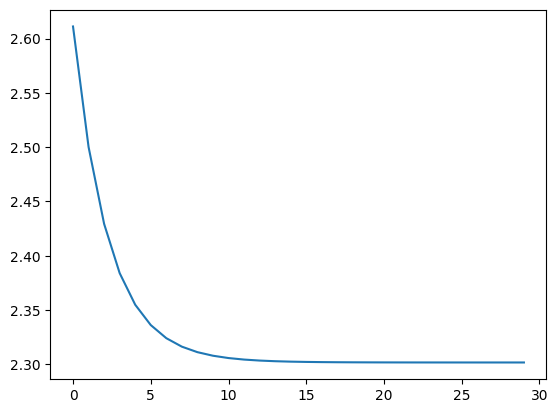

In [ ]:
# let's look at the loss history!
plt.plot(loss_history)

In [ ]:
def multiclass_accuracy(pred, val_y):
  return len(pred[pred==val_y]) / len(pred)

In [ ]:
# Let's check how it performs on validation set
pred = classifier.predict(val_X)
print(pred[:30], val_y[:30], sep='\n')
accuracy = multiclass_accuracy(pred, val_y)
print("Accuracy: ", accuracy)

# Now, let's train more and see if it performs better
classifier.fit(train_X, train_y, epochs=100, learning_rate=1e-3, batch_size=300, reg=1e1)
pred = classifier.predict(val_X)
accuracy = multiclass_accuracy(pred, val_y)
print("Accuracy after training for 100 epochs: ", accuracy)

[2 4 4 3 5 7 5 1 2 5 5 1 4 4 4 4 5 1 5 1 5 5 5 5 5 4 4 1 4 4]
[2 9 8 4 6 5 3 3 3 1 1 7 5 2 8 8 3 3 2 3 3 7 3 1 4 8 1 7 0 1]
Accuracy:  0.123
Epoch 0, loss: 2.301705
Epoch 1, loss: 2.301705
Epoch 2, loss: 2.301705
Epoch 3, loss: 2.301705
Epoch 4, loss: 2.301705
Epoch 5, loss: 2.301705
Epoch 6, loss: 2.301705
Epoch 7, loss: 2.301705
Epoch 8, loss: 2.301705
Epoch 9, loss: 2.301705
Epoch 10, loss: 2.301705
Epoch 11, loss: 2.301705
Epoch 12, loss: 2.301705
Epoch 13, loss: 2.301705
Epoch 14, loss: 2.301705
Epoch 15, loss: 2.301705
Epoch 16, loss: 2.301705
Epoch 17, loss: 2.301705
Epoch 18, loss: 2.301705
Epoch 19, loss: 2.301705
Epoch 20, loss: 2.301705
Epoch 21, loss: 2.301704
Epoch 22, loss: 2.301704
Epoch 23, loss: 2.301704
Epoch 24, loss: 2.301704
Epoch 25, loss: 2.301704
Epoch 26, loss: 2.301704
Epoch 27, loss: 2.301704
Epoch 28, loss: 2.301704
Epoch 29, loss: 2.301704
Epoch 30, loss: 2.301704
Epoch 31, loss: 2.301704
Epoch 32, loss: 2.301704
Epoch 33, loss: 2.301704
Epoch 34, loss: 2.3

### Используем кросс-валидацию для подбора гиперпараметтов.

В этот раз, чтобы тренировка занимала разумное время, мы будем использовать только одно разделение на тренировочные (training) и проверочные (validation) данные.

Теперь нам нужно подобрать не один, а два гиперпараметра! Не ограничивайте себя изначальными значениями в коде.  
Добейтесь точности более чем **20%** на проверочных данных (validation data).

In [ ]:
num_epochs = 200
batch_size = 300

learning_rates = [2e-1, 17e-2, 15e-2, 13e-2, 1e-1, 7e-2, 5e-2]
reg_strengths = [3e-1, 5e-1, 7e-1, 1e-2, 15e-3, 2e-2, 25e-3]

best_classifier = None
best_val_accuracy = 0
best_lr = 0
best_rs = 0

for lr in learning_rates:
  for reg in reg_strengths:
    classifier = LinearSoftmaxClassifier()
    classifier.fit(train_X, train_y, epochs=num_epochs, learning_rate=lr, batch_size=batch_size, reg=reg)
    y_pred = classifier.predict(val_X)
    accuracy = multiclass_accuracy(y_pred, val_y)
    if accuracy > best_val_accuracy:
      best_val_accuracy = accuracy
      best_classifier = classifier
      best_lr = lr
      best_rs = reg

# TODO use validation set to find the best hyperparameters
# hint: for best results, you might need to try more values for learning rate and regularization strength
# than provided initially

print(f'best validation accuracy achieved: {best_val_accuracy}')

Выходные данные были обрезаны до нескольких последних строк (5000).
Epoch 1, loss: 2.229925
Epoch 2, loss: 2.167832
Epoch 3, loss: 2.232795
Epoch 4, loss: 2.181025
Epoch 5, loss: 2.239626
Epoch 6, loss: 2.191277
Epoch 7, loss: 2.262783
Epoch 8, loss: 2.218591
Epoch 9, loss: 2.173798
Epoch 10, loss: 2.157357
Epoch 11, loss: 2.239931
Epoch 12, loss: 2.175002
Epoch 13, loss: 2.173646
Epoch 14, loss: 2.166007
Epoch 15, loss: 2.195530
Epoch 16, loss: 2.218030
Epoch 17, loss: 2.151078
Epoch 18, loss: 2.181127
Epoch 19, loss: 2.197737
Epoch 20, loss: 2.166320
Epoch 21, loss: 2.223067
Epoch 22, loss: 2.175290
Epoch 23, loss: 2.205550
Epoch 24, loss: 2.131196
Epoch 25, loss: 2.187356
Epoch 26, loss: 2.224344
Epoch 27, loss: 2.152104
Epoch 28, loss: 2.175261
Epoch 29, loss: 2.168605
Epoch 30, loss: 2.183016
Epoch 31, loss: 2.192775
Epoch 32, loss: 2.148128
Epoch 33, loss: 2.173648
Epoch 34, loss: 2.164394
Epoch 35, loss: 2.184078
Epoch 36, loss: 2.145495
Epoch 37, loss: 2.181811
Epoch 38, loss: 

In [ ]:
print(multiclass_accuracy(best_classifier.predict(val_X), val_y)) #0.242
print(best_lr, best_rs)

0.247
0.1 0.01


# Какой же точности мы добились на тестовых данных?

In [ ]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Linear softmax classifier test set accuracy: %f' % (test_accuracy, )) #(0.251, 0.210)

Linear softmax classifier test set accuracy: 0.204000
